# Beschreibung #

# CVA-Eigenwerte für Tennessee Eastman Process (TEP)

Dieses Notebook berechnet für jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) die **kanonischen Korrelationen der CVA**
(Canonical Variate Analysis) des jeweiligen Runs und fasst diese anschließend
über die 500 Läufe pro Fehlerklasse mittels Mittelwert und Standardabweichung
zusammen. Struktur und Konventionen sind identisch zu `DyCA_Eigenwerte.ipynb`.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien müssen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  → 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzept**

- **CVA** (Larimore) sucht die Richtungen maximaler Korrelation zwischen
  **Vergangenheit** und **Zukunft** des Prozesses. Hier in der einfachsten
  State-Space-Form mit Fensterlänge 1: Vergangenheit `p_t = x_{t−1}`,
  Zukunft `f_t = x_t`. Die **kanonischen Korrelationen** (52 Werte in
  [0, 1], absteigend sortiert) messen die *Ein-Schritt-Vorhersagbarkeit*
  der kanonischen Richtungen — das direkte CVA-Gegenstück zum
  DyCA-Eigenwertspektrum (dort das Verhältnis von Ableitungs- zu
  Signalkorrelationen, ebenfalls in [0, 1]).
- **Warum Fensterlänge p = f = 1?** Bei größeren Fenstern (z. B. p = f = 3
  → 156-dimensionale Vergangenheit/Zukunft aus nur ~475 Samples) sind die
  geschätzten kanonischen Korrelationen massiv nach oben verzerrt
  (Schein-Korrelationen der Größenordnung √(dim/N) pro Seite) — das
  Spektrum sättigt nahe 1 und wird uninformativ. Mit p = f = 1
  (52 Dimensionen aus 479 Paaren) bleibt die Schätzung tragfähig, und es
  entstehen exakt **52 Werte** — direkt vergleichbar mit den 52 Eigenwerten
  aus dem PCA- und DyCA-Notebook. `CVA_PAST`/`CVA_FUT` sind Parameter.
- Mathematik: zentrierte Kovarianzen `Σ_pp`, `Σ_ff`, `Σ_fp`; die
  kanonischen Korrelationen sind die Singulärwerte von
  `H = Σ_ff^(−1/2) · Σ_fp · Σ_pp^(−1/2)`. Eine relative
  Ridge-Regularisierung (wie im LDA-Notebook) stabilisiert die
  Inversion — die 52 TEP-Variablen sind durch Bilanzgleichungen
  quasi-linear abhängig.
- **Skalierungs-Invarianz** (Gegenstück zur m/n-Notiz im DyCA-Notebook):
  kanonische Korrelationen sind invariant gegenüber separaten
  invertierbaren affinen Transformationen von Vergangenheit und Zukunft.
  Zwischen der aktiven Variante (`X_scaled = X - X.mean()`, Konvention
  aller Eigenwert-Notebooks) und der spaltenweisen Standardisierung
  (`scaler.transform(X)`) ändern sich die exportierten Werte also
  praktisch **nicht** — nachgemessen: maximale Abweichung ~8·10⁻⁷, ein
  Rest-Effekt der Ridge-Regularisierung.
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen. Konsequenz: Fault 0 nutzt 500 Beobachtungen pro Run
  (499 Paare), Fault 1-20 jeweils 480 (479 Paare).
- Fehlerbehandlung wie im DyCA-Notebook (try/except pro Run,
  Diagnose-Zelle) — dank Ridge-Regularisierung sind Ausfälle hier aber
  selten bis nie zu erwarten.
- Über die verbliebenen Läufe einer Fehlerklasse werden für jeden
  Eigenwertindex Mittelwert und Standardabweichung gebildet.


# Imports #

In [1]:
# !pip install matplotlib numpy pandas scikit-learn tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["font.size"] = 10

# Parameter #

In [2]:
# ===== Pfade zu den TEP-CSV-Dateien =====
PATH_FAULTFREE_TRAIN = "TEP_FaultFree_Training.csv"
PATH_FAULTY_TRAIN    = "TEP_Faulty_Training.csv"

# ===== Prozessvariablen (wie im PCA-/DyCA-Notebook) =====
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS

META_COLS  = ["faultNumber", "simulationRun", "sample"]

# ===== CVA-Parameter =====
# Fensterlaengen fuer Vergangenheit und Zukunft:
#   p_t = [x_{t-1}, ..., x_{t-CVA_PAST}],  f_t = [x_t, ..., x_{t+CVA_FUT-1}]
# BEWUSST 1/1: groessere Fenster (z.B. 3/3 -> 156 Dimensionen je Seite
# aus nur ~475 Samples) erzeugen massiv nach oben verzerrte Schein-
# Korrelationen (Groessenordnung sqrt(dim/N) je Seite) - das Spektrum
# saettigt dann nahe 1 und wird uninformativ. Mit 1/1 entstehen exakt
# 52 Werte, direkt vergleichbar mit PCA/DyCA (Begruendung siehe oben).
CVA_PAST = 1
CVA_FUT  = 1

# Relative Ridge-Regularisierung der Kovarianzmatrizen (wie RIDGE_REL im
# LDA-Notebook):  S <- S + RIDGE_REL * (trace(S)/p) * I
# Stabilisiert die inverse Wurzel, weil die 52 TEP-Variablen durch
# Massen-/Stoffbilanzen quasi-linear abhaengig sind.
RIDGE_REL = 1e-6

# Erster Sample-Index, der als 'post-fault' gilt (siehe Beschreibung).
PRE_FAULT_CUTOFF = 21

# Daten laden & Spalten prüfen #

In [3]:
# ============================================================
# Trainingsdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im aktuellen Arbeitsverzeichnis liegen.
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

df_ff_train     = pd.read_csv(PATH_FAULTFREE_TRAIN)
df_faulty_train = pd.read_csv(PATH_FAULTY_TRAIN)

# Nur die benoetigten Spalten behalten (Metadaten + Prozessvariablen).
df_ff_train     = df_ff_train[META_COLS + PROC_COLS]
df_faulty_train = df_faulty_train[META_COLS + PROC_COLS]

print("FaultFree_Training shape:", df_ff_train.shape)
print("Faulty_Training shape   :", df_faulty_train.shape)

# ------------------------------------------------------------
# Spalten-Check
# ------------------------------------------------------------
for col in META_COLS:
    if col not in df_ff_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in df_faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

print("Anzahl Prozessvariablen:", len(PROC_COLS))
print("Beispiel-Variablen:", PROC_COLS[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# StandardScaler auf FaultFree_Training fitten (wird in der Schleife angewandt) #

In [4]:
# ============================================================
# StandardScaler auf FaultFree_Training (Normalbetrieb) fitten
# ============================================================
# Dieser Scaler ist aktuell UNGENUTZT: aktiv ist X_scaled = X - X.mean()
# (global_mean) in run_cva_on_group - Konvention aller Eigenwert-
# Notebooks. Fuer die EXPORTIERTEN Werte ist die Wahl nachweislich fast
# egal: kanonische Korrelationen sind invariant gegenueber spaltenweisen
# affinen Transformationen (siehe Beschreibung); die Zeile wird nur der
# Konsistenz halber mitgeschaltet.

scaler = StandardScaler()
scaler.fit(df_ff_train[PROC_COLS].values)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Features:        ", len(PROC_COLS))
print("  Mittelwerte (Auszug):   ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):     ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Features:         52
  Mittelwerte (Auszug):    [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):      [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# Trainingsdaten zusammenführen (Fault 0-20) #

In [5]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Eine Schleife laeuft anschliessend ueber alle Kombinationen
# (faultNumber, simulationRun).
#
# Globale Sortierung nach (Fault, Run, Sample): CVA bildet Paare
# aufeinanderfolgender Zeitpunkte (x_{t-1}, x_t) - die Zeilen jeder
# Gruppe muessen zeitlich geordnet vorliegen (wie bei DyCA).

df_all = pd.concat([df_ff_train, df_faulty_train], ignore_index=True)
df_all = df_all.sort_values(
    ["faultNumber", "simulationRun", "sample"]
).reset_index(drop=True)

print("Kombinierte Trainingsdaten shape:", df_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(df_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# Funktion: CVA-Eigenwerte pro Run #

In [6]:
def _inv_sqrt_psd(S, ridge_rel=RIDGE_REL):
    """Inverse Matrixwurzel S^(-1/2) einer symmetrischen, positiv
    semidefiniten Matrix - mit relativer Ridge-Regularisierung und
    Clipping numerisch negativer Eigenwerte.

    Ridge wie im LDA-Notebook: S <- S + ridge_rel * (trace(S)/p) * I.
    Danach Eigenzerlegung S = V diag(w) V^T und
    S^(-1/2) = V diag(1/sqrt(w)) V^T.
    """
    p = S.shape[0]
    S = S + ridge_rel * (np.trace(S) / p) * np.eye(p)
    w, V = np.linalg.eigh(S)
    # Floating-Point-Rauschen kann winzige negative Eigenwerte erzeugen;
    # Clipping relativ zum groessten Eigenwert haelt die Wurzel reell.
    w = np.maximum(w, 1e-12 * w.max())
    return (V / np.sqrt(w)) @ V.T


def run_cva_on_group(
    group: pd.DataFrame,
    scaler: StandardScaler,
    proc_cols: list,
    past: int = CVA_PAST,
    fut: int = CVA_FUT,
    ridge_rel: float = RIDGE_REL,
):
    """
    Fuehrt CVA auf einem einzelnen (faultNumber, simulationRun)-Subsample
    aus und gibt das Array der kanonischen Korrelationen zurueck.

    Vorgehen
    --------
    1. Vergangenheits- und Zukunftsvektoren stapeln:
         p_t = [x_{t-1}, ..., x_{t-past}]   (52*past Dimensionen)
         f_t = [x_t, ..., x_{t+fut-1}]      (52*fut Dimensionen)
       mit t = past .. T-fut  ->  N = T - past - fut + 1 Paare.
    2. Beide Seiten spaltenweise zentrieren (Teil der CVA-Definition -
       unabhaengig von der umschaltbaren Vorverarbeitung davor) und die
       Kovarianzen S_pp, S_ff, S_fp bilden.
    3. H = S_ff^(-1/2) @ S_fp @ S_pp^(-1/2); die Singulaerwerte von H
       sind die kanonischen Korrelationen - in [0, 1] und von der SVD
       bereits absteigend sortiert.

    Parameter
    ---------
    group : pd.DataFrame
        Genau EIN Run, Zeilen = Samples in zeitlicher Reihenfolge.
    scaler : StandardScaler
        Auf FaultFree gefittet, hier aktuell UNGENUTZT (aktiv ist
        X_scaled = X - X.mean()). Fuer die kanonischen Korrelationen
        ist die Wahl ohnehin (bis auf Ridge-Effekte ~1e-6) folgenlos,
        siehe Invarianz-Notiz in der Beschreibung.
    proc_cols : list[str]
        Prozessvariablen-Spalten (xmeas_*, xmv_*).
    past, fut : int
        Fensterlaengen (siehe Parameter-Zelle).
    ridge_rel : float
        Relative Ridge-Regularisierung der Kovarianzen.

    Rueckgabewert
    -------------
    corrs : np.ndarray
        Kanonische Korrelationen, shape (min(52*past, 52*fut),) = 52 bei
        past=fut=1, absteigend sortiert, auf [0, 1] geclippt.
    """

    # 0) Defensive Sortierung nach 'sample' - CVA paart aufeinander-
    # folgende Zeitpunkte, die Reihenfolge muss zeitlich korrekt sein.
    if "sample" in group.columns:
        group = group.sort_values("sample")

    # 1) Messmatrix dieses Runs extrahieren.
    # Shape: (n_samples, n_features) = z.B. (480, 52)
    X = group[proc_cols].values.astype(np.float64)

    # 2) Vorverarbeitung: Abzug des skalaren Gesamtmittelwerts
    # (global_mean, Konvention aller Eigenwert-Notebooks). Die CVA
    # zentriert ihre Vergangenheits-/Zukunftsvektoren unten ohnehin
    # spaltenweise - die Wahl ist hier praktisch folgenlos.
    X_scaled = X - X.mean()  # global_mean aktiv | Alternative: X_scaled = scaler.transform(X)

    # 3) Vergangenheit/Zukunft stapeln. Bei past=fut=1 schlicht:
    # P = x_{t-1} (Zeilen 0..T-2), F = x_t (Zeilen 1..T-1).
    T = X_scaled.shape[0]
    P = np.hstack([X_scaled[past - j: T - fut + 1 - j]
                   for j in range(1, past + 1)])
    F = np.hstack([X_scaled[past + j: T - fut + 1 + j]
                   for j in range(fut)])
    N = P.shape[0]

    # 4) Zentrieren + Kovarianzen (ddof=1-Konvention).
    Pc = P - P.mean(axis=0)
    Fc = F - F.mean(axis=0)
    Spp = Pc.T @ Pc / (N - 1)
    Sff = Fc.T @ Fc / (N - 1)
    Sfp = Fc.T @ Pc / (N - 1)

    # 5) Kanonische Korrelationen als Singulaerwerte von H.
    H = _inv_sqrt_psd(Sff, ridge_rel) @ Sfp @ _inv_sqrt_psd(Spp, ridge_rel)
    corrs = np.linalg.svd(H, compute_uv=False)

    # Numerisches Rauschen kann Werte minimal ueber 1 druecken -> clippen.
    return np.clip(corrs, 0.0, 1.0)


def compute_cva_eigenvalues_per_run(
    df: pd.DataFrame,
    proc_cols: list,
    scaler: StandardScaler,
    past: int = CVA_PAST,
    fut: int = CVA_FUT,
    ridge_rel: float = RIDGE_REL,
    drop_pre_fault: bool = True,
    pre_fault_cutoff: int = PRE_FAULT_CUTOFF,
):
    """
    Erzeugt einen DataFrame mit kanonischen CVA-Korrelationen pro
    (faultNumber, simulationRun) - analog zu
    compute_dyca_eigenvalues_per_run im DyCA-Notebook.

    Rueckgabewert
    -------------
    df_eigs : pd.DataFrame
        Eine Zeile pro (faultNumber, simulationRun). Spalten:
            'faultNumber', 'simulationRun',
            'cva_1', 'cva_2', ..., 'cva_K'
        K = min(52*past, 52*fut) = 52 bei past=fut=1.
    """

    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne CVA-Eigenwerte pro Run")

    records      = []
    error_count  = 0
    skip_count   = 0
    first_errors = []

    for (fault, run), group in iterator:

        # Pre-Fault-Bereich verwerfen (nur Fault != 0).
        if drop_pre_fault and fault != 0:
            group = group[group["sample"] >= pre_fault_cutoff]

        # Robuste Untergrenze: fuer eine sinnvolle Schaetzung der
        # 52x52-Kovarianzen braucht es mehr Paare als Dimensionen.
        # Bei den vorliegenden Runlaengen (480/500) greift das nie.
        if len(group) < len(proc_cols) + past + fut + 5:
            skip_count += 1
            continue

        # Numerische Ausfaelle (z.B. SVD-Nichtkonvergenz) werden wie im
        # DyCA-Notebook gesammelt statt den Lauf abzubrechen; dank Ridge
        # sind sie hier aber selten bis nie zu erwarten.
        try:
            corrs = run_cva_on_group(
                group=group,
                scaler=scaler,
                proc_cols=proc_cols,
                past=past,
                fut=fut,
                ridge_rel=ridge_rel,
            )

            row = {
                "faultNumber":   fault,
                "simulationRun": run,
            }
            for k, val in enumerate(corrs, start=1):
                row[f"cva_{k}"] = float(val)
            records.append(row)

        except Exception as e:
            error_count += 1
            if len(first_errors) < 5:
                first_errors.append(f"  fault={fault}, run={run}: {e}")

    df_eigs = pd.DataFrame.from_records(records)

    # Spalten-Reihenfolge: meta zuerst, dann cva_1, cva_2, ...
    eig_cols = [c for c in df_eigs.columns if c.startswith("cva_")]
    eig_cols = sorted(eig_cols, key=lambda c: int(c.split("_")[1]))
    df_eigs  = df_eigs[["faultNumber", "simulationRun"] + eig_cols]

    print("Erfolgreiche Runs:", len(df_eigs))
    print("Uebersprungen   :", skip_count)
    print("Fehler          :", error_count)
    if first_errors:
        print("Erste Fehler:")
        for line in first_errors:
            print(line)

    return df_eigs

# Anwendung: CVA-Eigenwerte für alle (Fault, Run)-Kombinationen #

In [7]:
# CVA-Eigenwerte fuer alle Faults und Runs in den Trainingsdaten berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei einem
#   Sampling-Intervall von 3 min entspricht das 20 Samples Vorlauf,
#   d.h. das erste Post-Fault-Sample hat sample == 21.

cva_eigenvalues_per_run = compute_cva_eigenvalues_per_run(
    df=df_all,
    proc_cols=PROC_COLS,
    scaler=scaler,
    past=CVA_PAST,
    fut=CVA_FUT,
    ridge_rel=RIDGE_REL,
    drop_pre_fault=True,
    pre_fault_cutoff=PRE_FAULT_CUTOFF,
)

print("CVA-Eigenwerte pro Run shape:", cva_eigenvalues_per_run.shape)
cva_eigenvalues_per_run.head()

Berechne CVA-Eigenwerte pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500
Uebersprungen   : 0
Fehler          : 0
CVA-Eigenwerte pro Run shape: (10500, 54)


,faultNumber,simulationRun,cva_1,cva_2,cva_3,cva_4,cva_5,cva_6,cva_7,cva_8,...,cva_43,cva_44,cva_45,cva_46,cva_47,cva_48,cva_49,cva_50,cva_51,cva_52
0,0,1,0.999280,0.996864,0.955275,0.934767,0.901703,0.880111,0.878702,0.828803,...,0.108680,0.071971,0.060349,0.052133,0.034836,0.020216,0.011797,0.004668,0.001187,0.000065
1,0,2,0.999797,0.998919,0.976159,0.954822,0.923838,0.884566,0.879918,0.855931,...,0.095334,0.081843,0.066639,0.044187,0.039164,0.023266,0.012194,0.002032,0.000461,0.000264
2,0,3,0.999753,0.997826,0.983757,0.941505,0.898022,0.878020,0.861381,0.841849,...,0.094865,0.087332,0.066345,0.061204,0.030773,0.025354,0.016600,0.010526,0.000312,0.000037
3,0,4,0.999510,0.997462,0.974875,0.948447,0.904926,0.894956,0.880295,0.844718,...,0.102800,0.098683,0.070744,0.049497,0.043979,0.031360,0.015587,0.003881,0.000504,0.000024
4,0,5,0.999266,0.998254,0.958977,0.942172,0.902639,0.882856,0.874151,0.849138,...,0.097000,0.086587,0.058147,0.050096,0.044664,0.032201,0.013650,0.008147,0.000460,0.000210


# Diagnose: erfolgreiche Runs pro Fehlerklasse #

In [8]:
# ============================================================
# Diagnose: Verteilung der erfolgreichen Runs pro Fehlerklasse
# ============================================================
# Analog zum DyCA-Notebook. Dank Ridge-Regularisierung sollte CVA im
# Regelfall ALLE Runs verarbeiten - diese Zelle bestaetigt das (oder
# macht Verluste sichtbar, falls doch welche auftreten).

runs_per_fault = cva_eigenvalues_per_run.groupby("faultNumber").size()
loss_per_fault = 500 - runs_per_fault

print("Erfolgreiche Runs pro Fault:")
print(runs_per_fault.to_string())

losses = loss_per_fault[loss_per_fault > 0]
if len(losses) == 0:
    print("\nKein Verlust - alle 500 Runs pro Fault erfolgreich.")
else:
    print("\nVerlust pro Fault (von 500):")
    print(losses.to_string())
    print(f"\nGesamt-Verlust: {losses.sum()} / {21 * 500} "
          f"({100 * losses.sum() / (21 * 500):.2f} %)")

Erfolgreiche Runs pro Fault:
faultNumber
0     500
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
11    500
12    500
13    500
14    500
15    500
16    500
17    500
18    500
19    500
20    500

Kein Verlust - alle 500 Runs pro Fault erfolgreich.


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [9]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung jedes Eigenwerts
# ============================================================
# Ausgangspunkt: cva_eigenvalues_per_run hat eine Zeile pro (Fault, Run)
# mit den kanonischen Korrelationen als Spalten cva_1 .. cva_52.
# Ziel:          eine Zeile pro Fault mit Mittelwert UND Std jedes
#                Eigenwerts ueber die 500 Runs der Klasse.

# Spalten-Liste der Eigenwerte (alles, was mit "cva_" anfaengt).
eig_cols = [c for c in cva_eigenvalues_per_run.columns if c.startswith("cva_")]

# Gruppieren nach faultNumber und in EINEM Schritt mean+std je
# Eigenwert-Spalte aggregieren. pandas-Std benutzt ddof=1
# (Stichproben-Std), passt fuer N=500.
agg = (
    cva_eigenvalues_per_run
    .groupby("faultNumber")[eig_cols]
    .agg(["mean", "std"])
)

# MultiIndex-Spalten ('cva_1', 'mean') -> 'cva_1_mean' flachklopfen.
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# faultNumber war Group-Key (Index) - jetzt wieder als normale Spalte.
agg = agg.reset_index()

print("Aggregierte CVA-Eigenwert-Statistiken pro Fault:")
print("  shape:", agg.shape)
agg.head()

Aggregierte CVA-Eigenwert-Statistiken pro Fault:
  shape: (21, 105)


,faultNumber,cva_1_mean,cva_1_std,cva_2_mean,cva_2_std,cva_3_mean,cva_3_std,cva_4_mean,cva_4_std,cva_5_mean,...,cva_48_mean,cva_48_std,cva_49_mean,cva_49_std,cva_50_mean,cva_50_std,cva_51_mean,cva_51_std,cva_52_mean,cva_52_std
0,0,0.999441,0.000258,0.997614,0.000909,0.968550,0.008662,0.947752,0.007883,0.901938,...,0.024676,0.006106,0.013678,0.004817,0.004996,0.003017,0.000738,0.000488,0.000131,0.000120
1,1,0.999924,0.000006,0.999873,0.000020,0.999062,0.000114,0.989543,0.001273,0.983538,...,0.015473,0.004960,0.006832,0.002795,0.002139,0.001396,0.000186,0.000147,0.000028,0.000026
2,2,0.999948,0.000007,0.999494,0.000147,0.992109,0.002316,0.986025,0.003816,0.947909,...,0.018008,0.004885,0.009199,0.003421,0.003006,0.001851,0.000313,0.000255,0.000049,0.000044
3,3,0.999459,0.000251,0.997697,0.000882,0.969361,0.008553,0.948717,0.007853,0.903762,...,0.024952,0.005942,0.013777,0.004935,0.005111,0.002914,0.000785,0.000528,0.000130,0.000115
4,4,0.999458,0.000252,0.997702,0.000881,0.969524,0.008509,0.948890,0.007911,0.904675,...,0.024917,0.005770,0.013938,0.004844,0.005300,0.003023,0.000772,0.000515,0.000136,0.000118


# Visualisierung: mittlere Eigenwertspektren je Fehlerklasse #

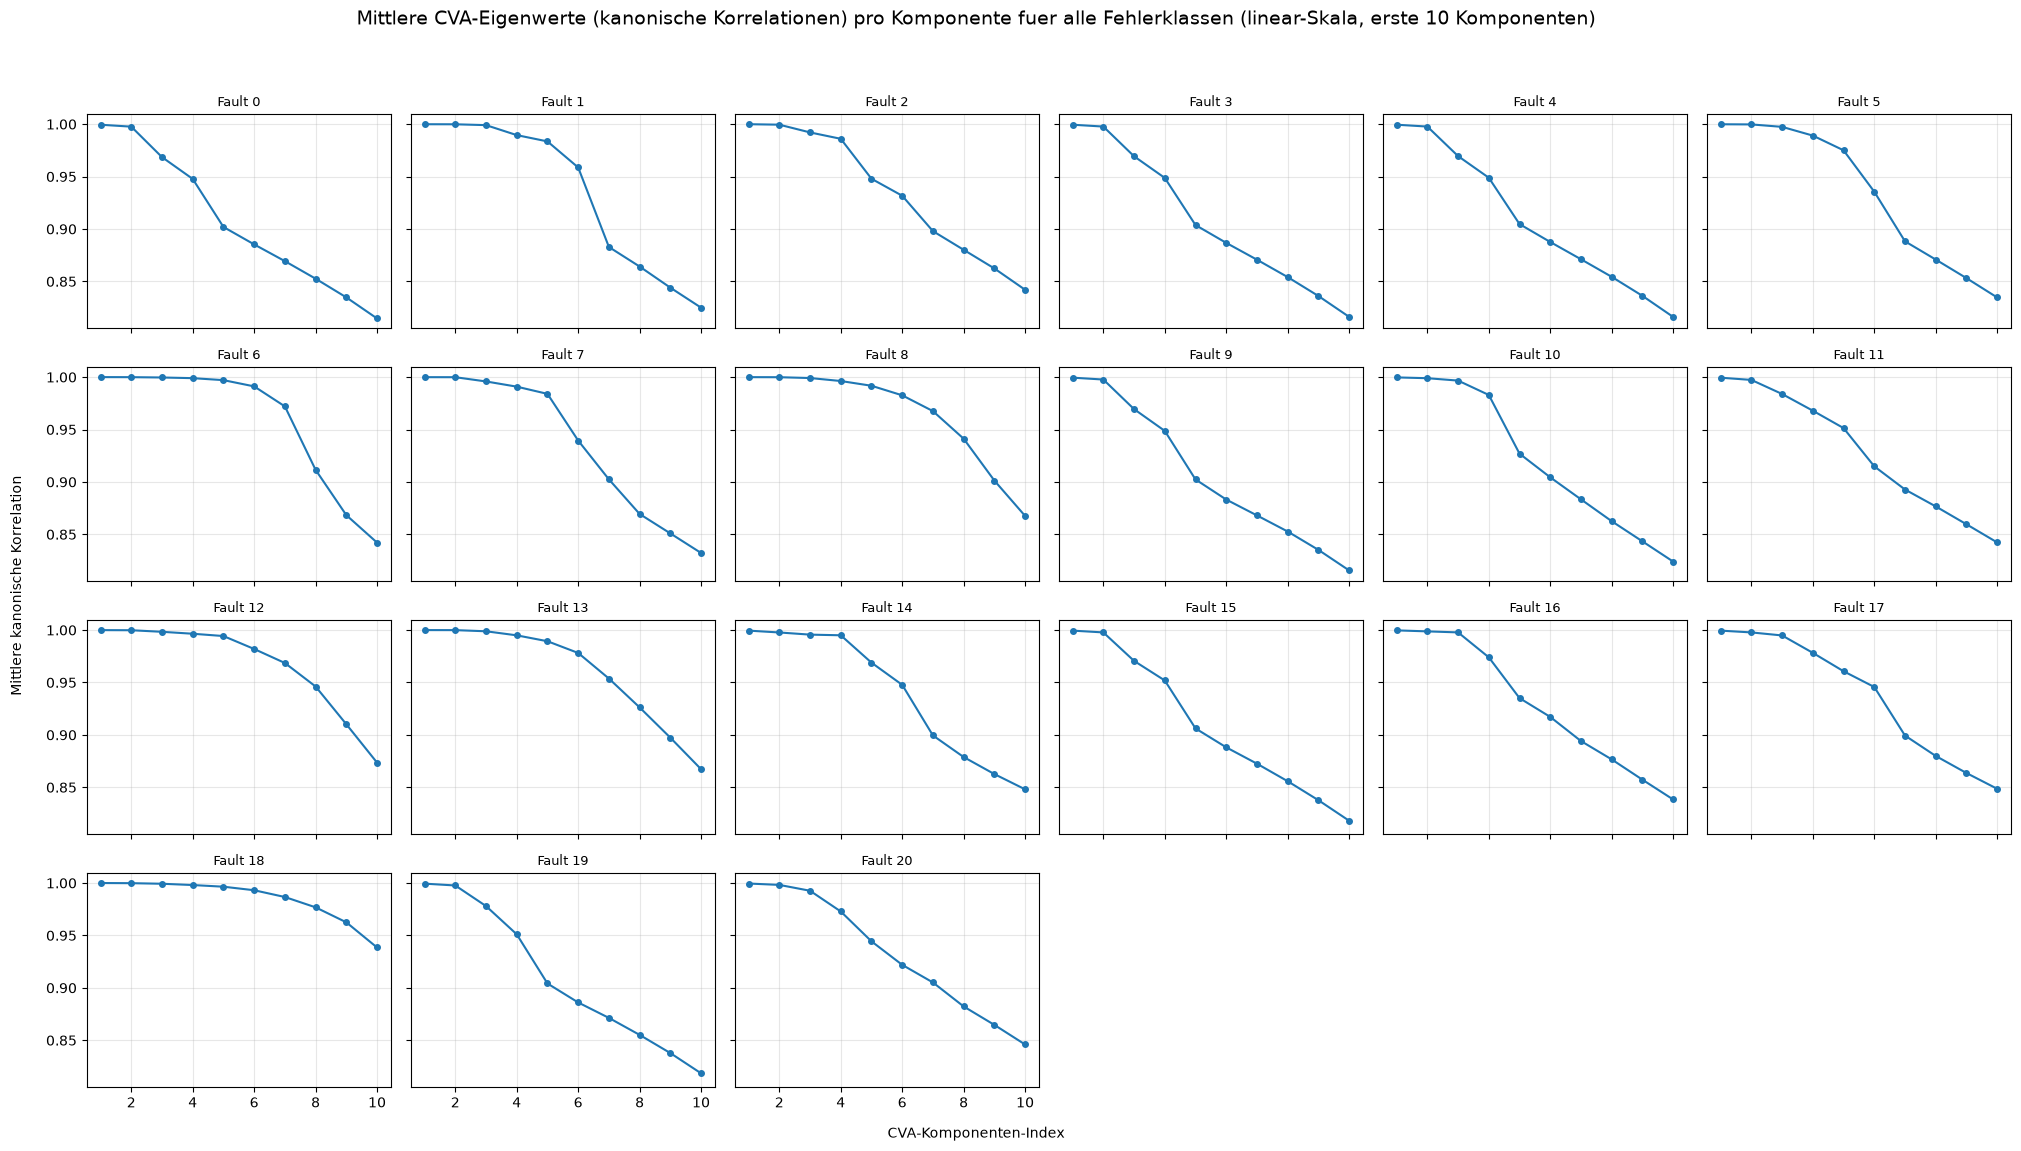

In [10]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der mittlere
# Eigenwertverlauf ueber die ersten k Komponenten.
# ============================================================

# Begrenzung der dargestellten Komponenten - analog zu K_MAX_DYCA im
# DyCA-Notebook. CVA gibt das volle Spektrum (52 Werte) zurueck, die
# hinteren Korrelationen sind aber nahe Null.
K_MAX_CVA = 10


# ============================================================
# Hilfsfunktion: Transformation der Eigenwerte vor dem Plotten
# ============================================================
def transform_eigenvalues(vals, mode="log"):
    """
    Transformiert einen Vektor von Eigenwerten fuer die Darstellung.

    mode = "linear"   -> keine Transformation. Bei CVA gut lesbar,
                         weil kanonische Korrelationen in [0, 1] liegen.
    mode = "log"      -> log10(Eigenwert). Macht Groessenordnungs-
                         Unterschiede sichtbar (sinnvoll beim vollen
                         Spektrum mit cva_52 nahe 0).
    mode = "relative" -> Eigenwert / cva_1. Zeigt nur das "Profil"
                         des Spektrums, unabhaengig vom Absolutniveau.
    """
    vals = np.asarray(vals, dtype=float)

    if mode == "linear":
        return vals

    if mode == "log":
        # log10(0) ist -inf -> kleinen Offset einsetzen, um Plot-NaNs zu vermeiden.
        eps = 1e-12
        return np.log10(np.maximum(vals, eps))

    if mode == "relative":
        if vals[0] <= 0:
            return vals
        return vals / vals[0]

    raise ValueError(f"Unbekannter mode: {mode}")


# Darstellungsmodus fuer Mittelwert- UND Std-Plot:
#   "linear"   -> rohe Werte (bei CVA in [0, 1] gut lesbar)
#   "log"      -> log10, empfohlen wenn das volle Spektrum geplottet wird
#   "relative" -> normiert auf cva_1, zeigt nur die Form des Spektrums
plot_mode = "linear"


def plot_cva_means_per_fault(agg_df, eig_prefix="cva_", k_max=K_MAX_CVA):
    # Alle Mittelwert-Spalten aufsteigend nach Komponenten-Index sortieren.
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))

    # Auf die ersten k_max Komponenten begrenzen.
    eig_cols_mean = eig_cols_mean[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    # Subplot-Raster (max 6 Spalten - wie im PCA-/DyCA-Notebook).
    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_mean], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    # Unbenutzte Achsen ausblenden.
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode == "log":
        y_label = "log10(Mittlere kanonische Korrelation)"
    elif plot_mode == "relative":
        y_label = "Mittlere kanonische Korrelation / cva_1"
    else:
        y_label = "Mittlere kanonische Korrelation"

    fig.suptitle(
        f"Mittlere CVA-Eigenwerte (kanonische Korrelationen) pro Komponente "
        f"fuer alle Fehlerklassen ({plot_mode}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "CVA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_cva_means_per_fault(agg)

# Visualisierung: Standardabweichungs-Spektren je Fehlerklasse #

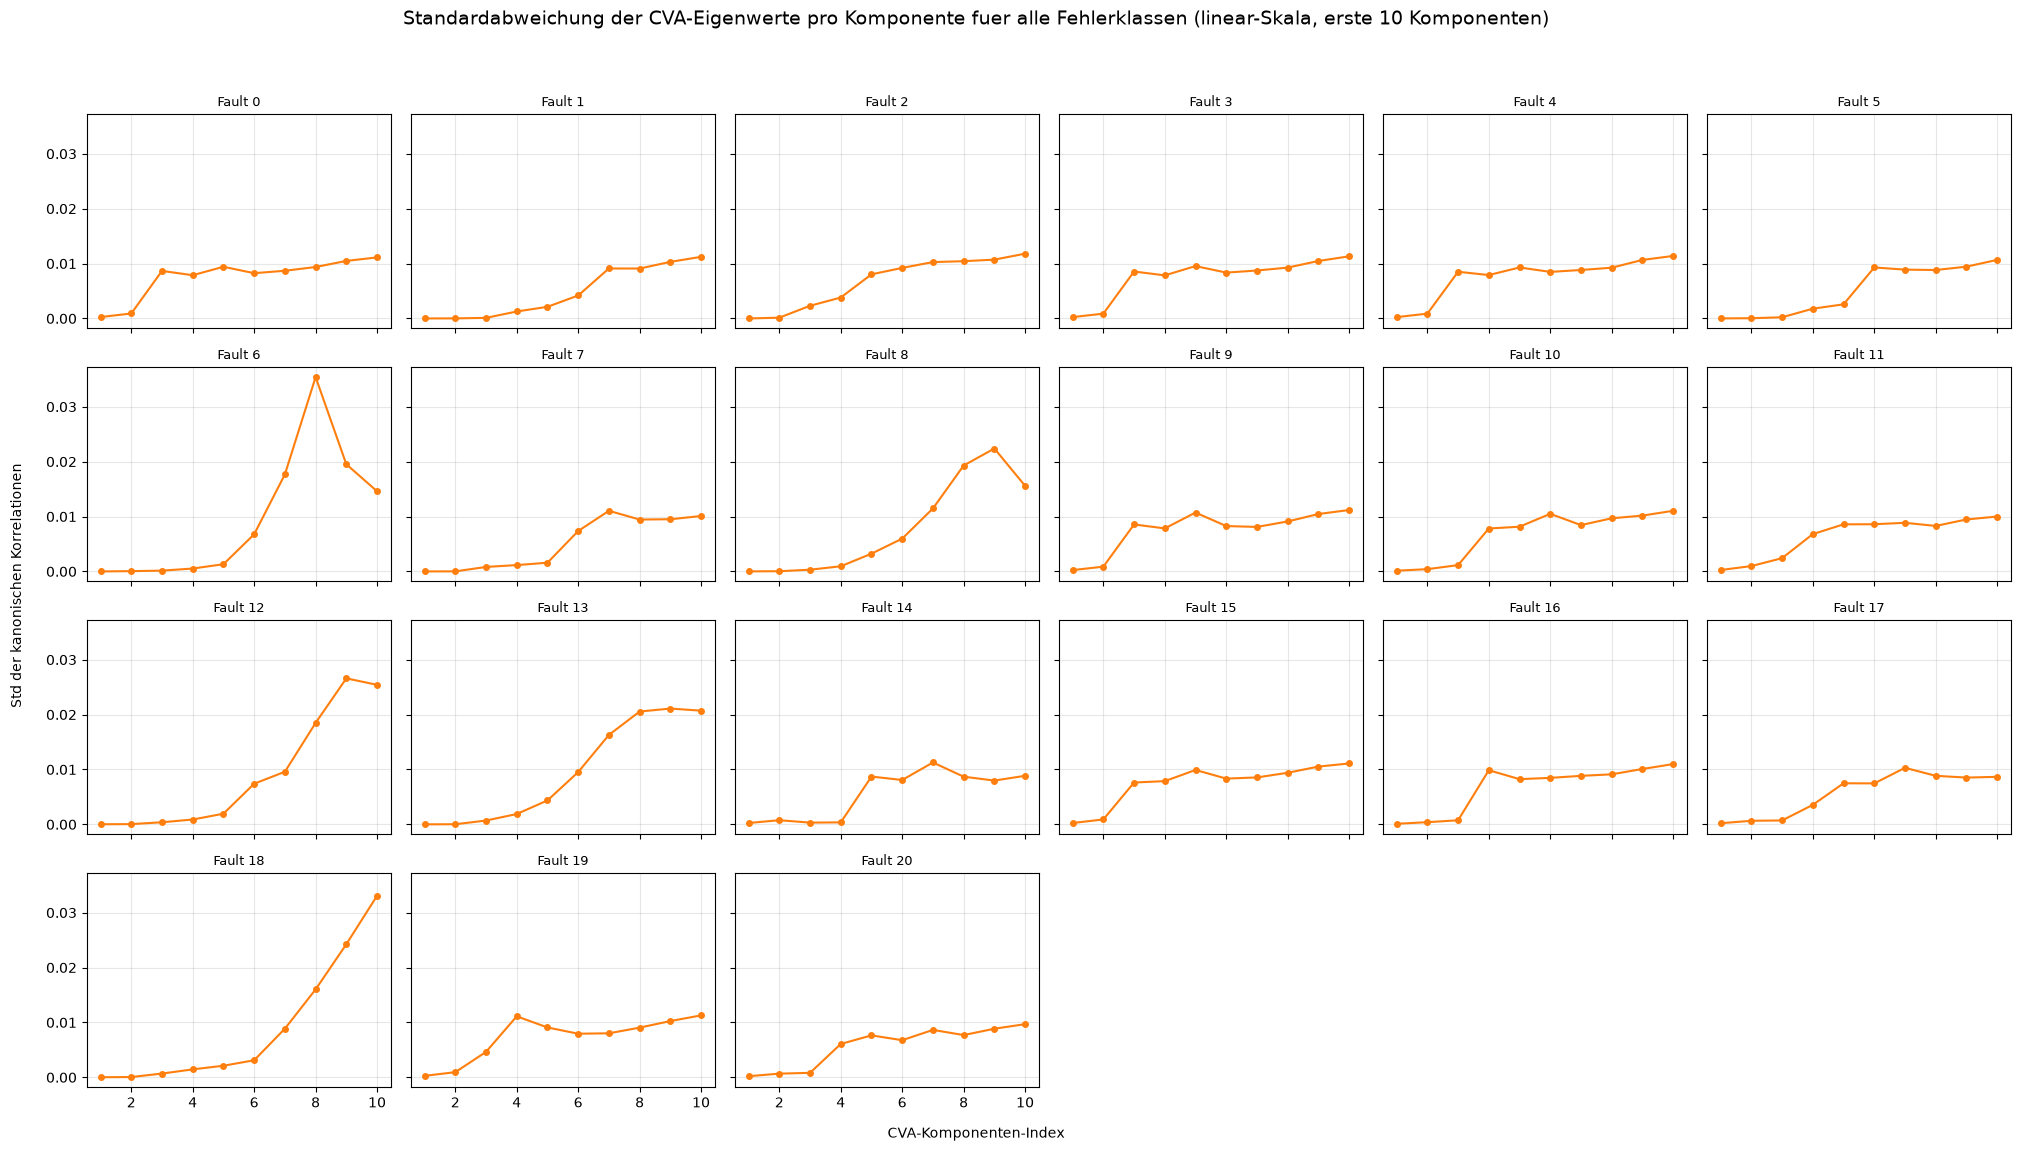

In [11]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der STANDARDABWEICHUNG der Eigenwerte ueber die ersten k Komponenten.
# Struktur identisch zum Mittelwerts-Plot, orange Linienfarbe.
# K_MAX_CVA, transform_eigenvalues und plot_mode kommen aus der
# Mittelwerts-Zelle.
# ============================================================

def plot_cva_stds_per_fault(agg_df, eig_prefix="cva_", k_max=K_MAX_CVA):
    eig_cols_std = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_std = sorted(eig_cols_std, key=lambda c: int(c.split("_")[1]))

    # Auf die ersten k_max Komponenten begrenzen.
    eig_cols_std = eig_cols_std[:k_max]
    K = len(eig_cols_std)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_std], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", color="tab:orange", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode == "log":
        y_label = "log10(Std der kanonischen Korrelationen)"
    elif plot_mode == "relative":
        y_label = "Std_i / Std_1"
    else:
        y_label = "Std der kanonischen Korrelationen"

    fig.suptitle(
        f"Standardabweichung der CVA-Eigenwerte pro Komponente fuer alle "
        f"Fehlerklassen ({plot_mode}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "CVA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_cva_stds_per_fault(agg)

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

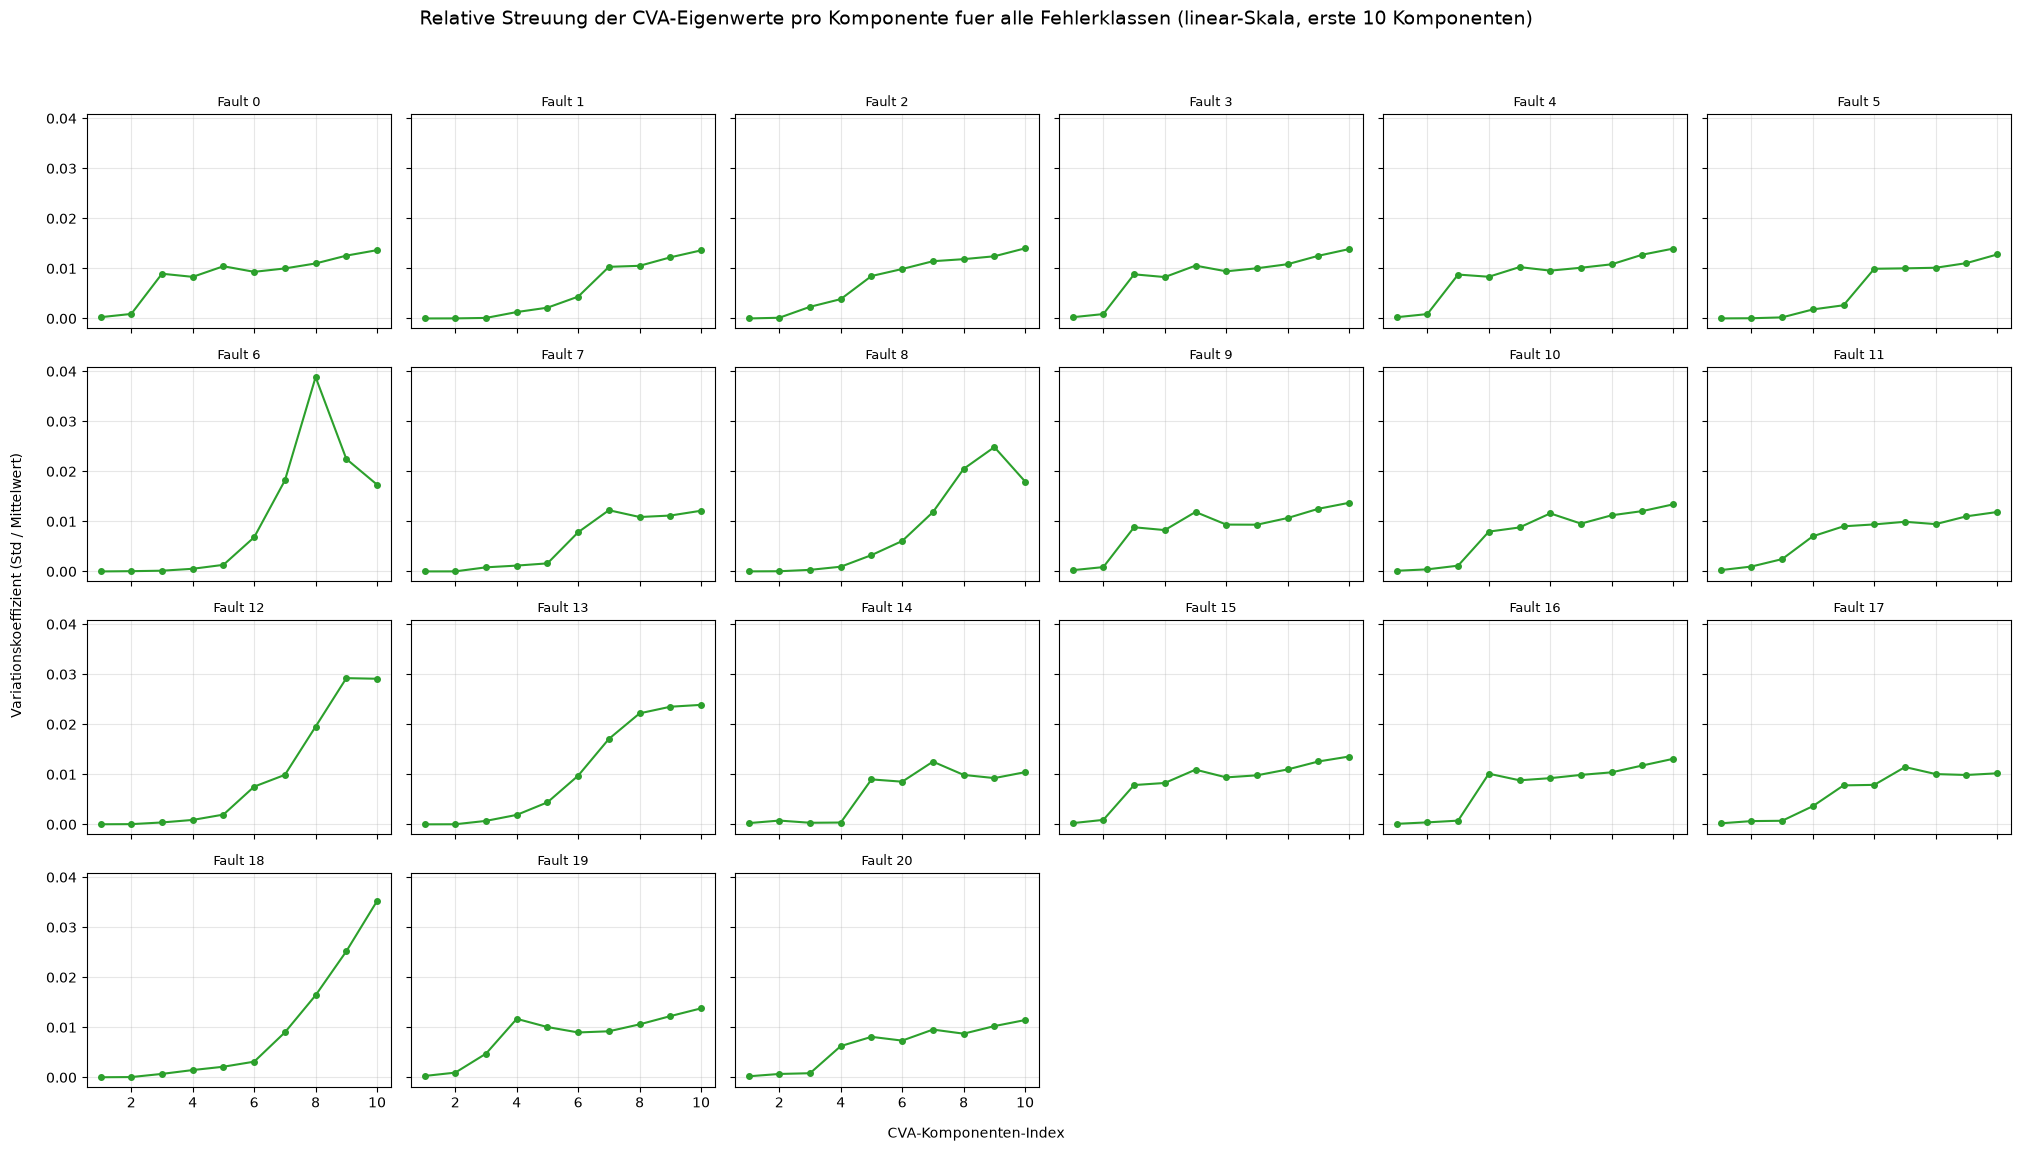

In [12]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der RELATIVEN STREUUNG (Variationskoeffizient) der Eigenwerte
# ueber die ersten k Komponenten.
#
#     CV_i = cva_i_std / cva_i_mean
#
# K_MAX_CVA und transform_eigenvalues kommen aus der Mittelwerts-Zelle.
# ============================================================

# Eigener Skalen-Modus fuer diesen Plot - bewusst LINEAR, weil CVs
# dimensionslose Verhaeltnisse sind und meist im Bereich 0..1 liegen.
plot_mode_cv = "linear"


def plot_cva_cv_per_fault(agg_df, eig_prefix="cva_", k_max=K_MAX_CVA):
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_std  = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))
    eig_cols_std  = sorted(eig_cols_std,  key=lambda c: int(c.split("_")[1]))

    eig_cols_mean = eig_cols_mean[:k_max]
    eig_cols_std  = eig_cols_std[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        mean_vals = np.array([row[c] for c in eig_cols_mean], dtype=float)
        std_vals  = np.array([row[c] for c in eig_cols_std],  dtype=float)

        # CV elementweise; bei mean nahe 0 -> NaN.
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = np.where(mean_vals > 0, std_vals / mean_vals, np.nan)

        y_vals = transform_eigenvalues(cv, mode=plot_mode_cv)

        ax.plot(x, y_vals, "o-", color="tab:green", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode_cv == "log":
        y_label = "log10(CV) = log10(Std / Mittelwert)"
    elif plot_mode_cv == "relative":
        y_label = "CV_i / CV_1"
    else:
        y_label = "Variationskoeffizient (Std / Mittelwert)"

    fig.suptitle(
        f"Relative Streuung der CVA-Eigenwerte pro Komponente fuer alle "
        f"Fehlerklassen ({plot_mode_cv}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "CVA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_cva_cv_per_fault(agg)

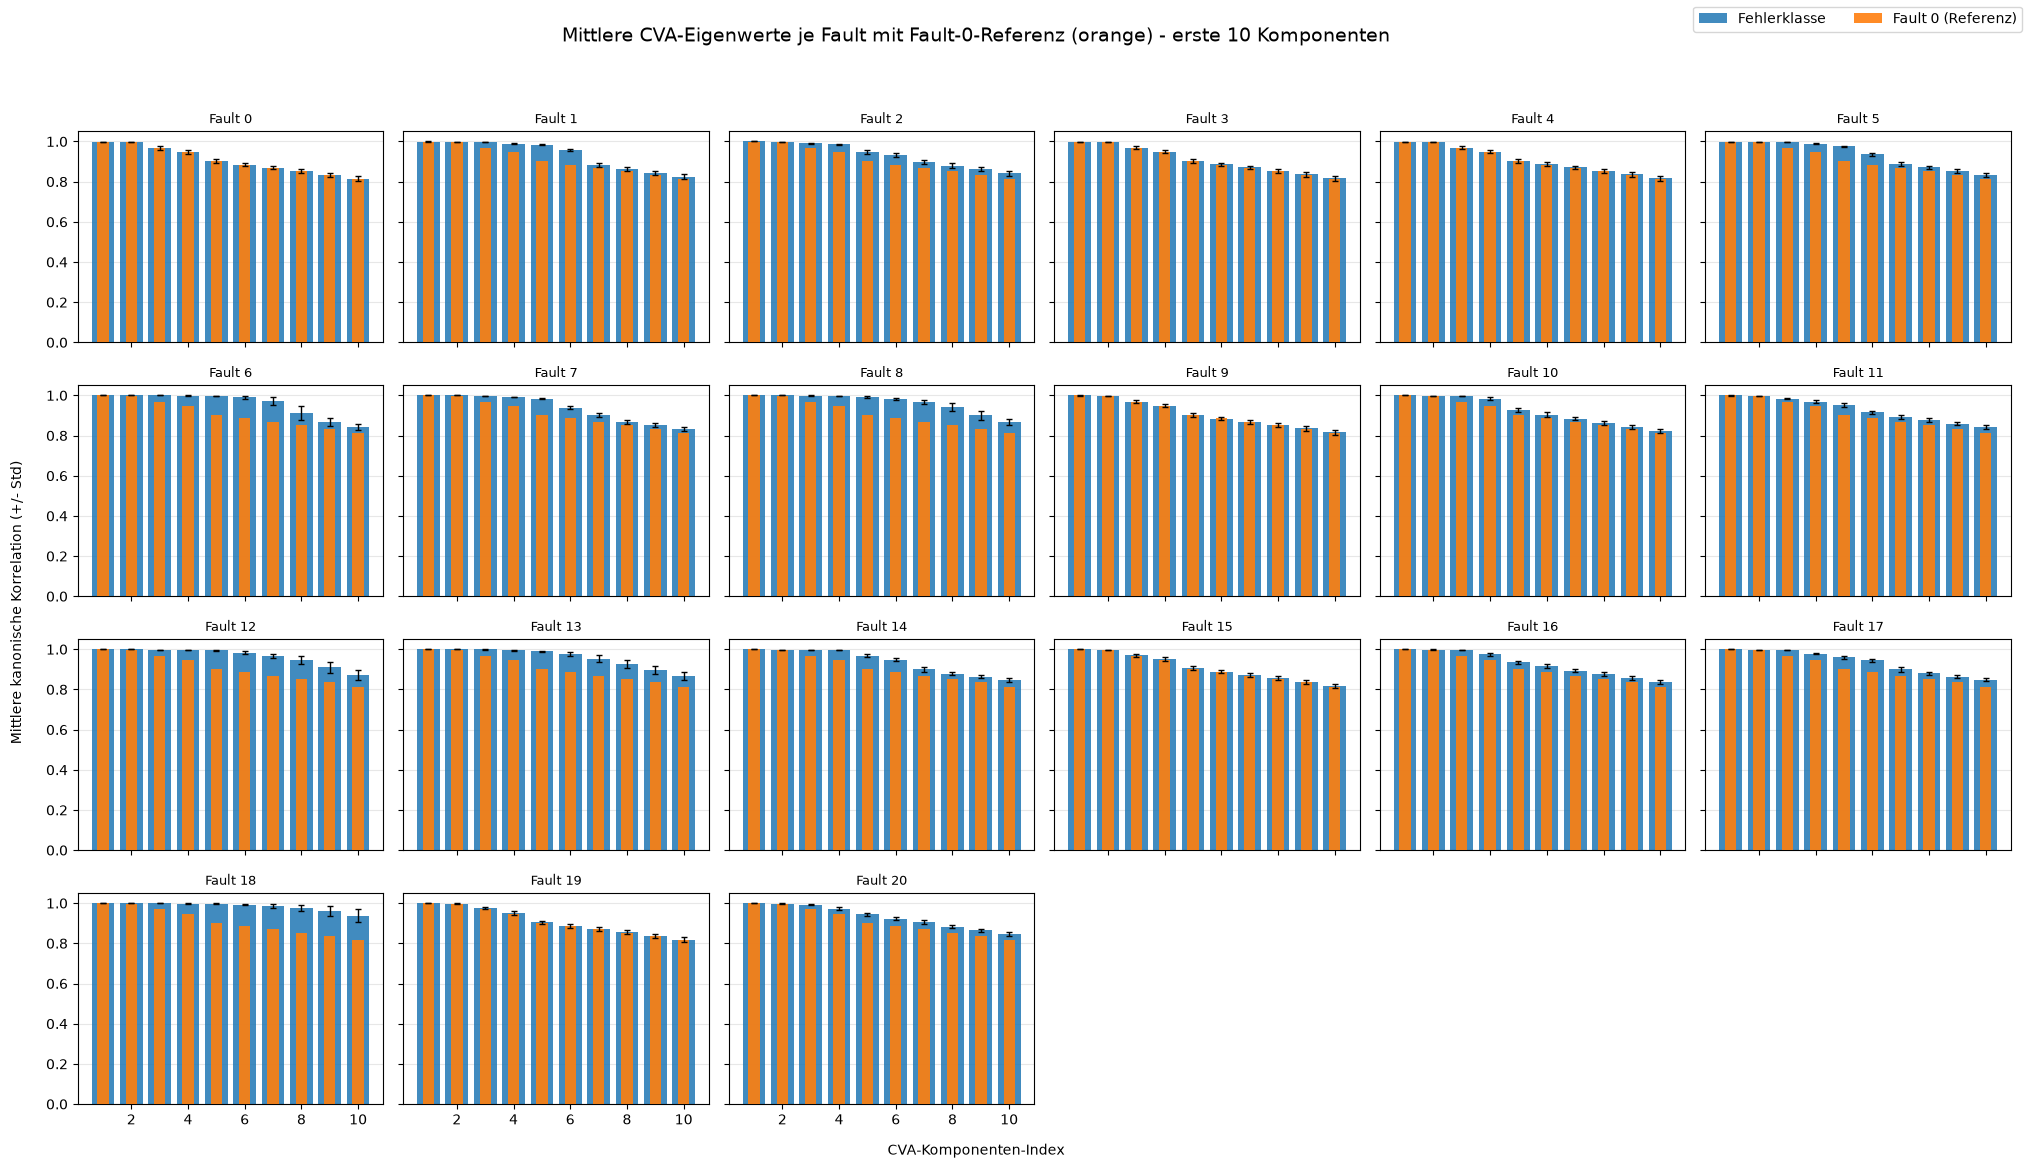

In [13]:
# ============================================================
# Bar-Plot: erste k CVA-Eigenwerte je Fault MIT Fault-0-Overlay
# ============================================================
# Pro Fehlerklasse ein Subplot:
#   - breite blaue Balken  = mittlere kanonische Korrelation der Klasse,
#   - schmale orange Balken= Mittelwert von Fault 0 (Normalbetrieb),
#                            zentriert oben drauf als Referenz,
#   - schwarze Fehlerbalken= +/- Std ueber die erfolgreichen Runs, werden
#                            ZULETZT gezeichnet (hoechster zorder), damit
#                            sie nicht vom orange Balken verdeckt werden.
# So ist je Fault direkt ablesbar, welche der ersten k Komponenten vom
# fehlerfreien Betrieb abweichen.
#
# Lesehilfe: Faults mit fast deckungsgleicher orange Referenz sind anhand
# des Spektrums kaum vom Normalbetrieb zu unterscheiden. Der Subplot
# "Fault 0" zeigt die Referenz auf sich selbst (Sanity-Check).

def plot_cva_bars_with_ref(agg_df, eig_prefix="cva_", k_bar=10):
    mean_cols_bar = [f"{eig_prefix}{i}_mean" for i in range(1, k_bar + 1)]
    std_cols_bar  = [f"{eig_prefix}{i}_std"  for i in range(1, k_bar + 1)]

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)
    ncols    = 6
    nrows    = int(np.ceil(n_faults / ncols))

    # Referenz-Spektrum: Mittelwerte von Fault 0 (Normalbetrieb).
    ref_means = agg_df[agg_df["faultNumber"] == 0].iloc[0][mean_cols_bar].values.astype(float)

    x = np.arange(1, k_bar + 1)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for i, f in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == f].iloc[0]
        means = row[mean_cols_bar].values.astype(float)
        stds  = row[std_cols_bar].values.astype(float)

        ax.bar(x, means, width=0.8,
               color="C0", alpha=0.85,
               label="Fehlerklasse", zorder=2)
        ax.bar(x, ref_means, width=0.4,
               color="tab:orange", alpha=0.9,
               label="Fault 0 (Referenz)", zorder=3)
        ax.errorbar(x, means, yerr=stds, fmt="none",
                    ecolor="black", capsize=2, elinewidth=1, zorder=4)

        ax.set_title(f"Fault {f}", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)

    for j in range(n_faults, len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10)

    fig.suptitle(
        f"Mittlere CVA-Eigenwerte je Fault mit Fault-0-Referenz (orange) "
        f"- erste {k_bar} Komponenten",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "CVA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  "Mittlere kanonische Korrelation (+/- Std)",
             va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_cva_bars_with_ref(agg)

In [14]:
# ============================================================
# Export: CVA-Eigenwerte (Training) als CSV
# ============================================================
# Stellt die TRAININGS-Eigenwerte fuer ein LazyClassifier-Notebook bereit.
# Die TEST-Eigenwerte werden bewusst NICHT hier berechnet, sondern -
# analog zu LazyClassifier_PCA_DyCA.ipynb - dort mit Cutoff 161 und
# Fenster-Angleich; dieses Notebook bleibt training-only.
cva_eigenvalues_per_run.to_csv("cva_eigenvalues_train.csv", index=False)
print("CVA-Train gespeichert:", cva_eigenvalues_per_run.shape,
      "-> cva_eigenvalues_train.csv")

CVA-Train gespeichert: (10500, 54) -> cva_eigenvalues_train.csv
